<a href="https://colab.research.google.com/github/SKKammar/Titanic-Survival-Prediction/blob/main/TitanicSurvivalPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/SKKammar/Titanic-Survival-Prediction/main/train.csv')
print("Dataset loaded successfully. Shape:", df.shape)
df.head()

print("First 5 rows:")
print(df.head())
print("\nDataset info:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully. Shape: (891, 12)
First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123       

# Extract Features

In [3]:
df_clean = df.copy()

# Extract Title from Name
df_clean['Title'] = df_clean['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

# Map rare titles to 'Rare'
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Rare', 'Countess': 'Rare', 'Ms': 'Rare', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Rare',
    'Capt': 'Rare', 'Sir': 'Rare'
}
df_clean['Title'] = df_clean['Title'].map(title_mapping)

# Family size
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# Drop unnecessary columns (including Embarked, which we saw was weak)
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked']
df_clean = df_clean.drop(drop_cols, axis=1)

# Define features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Title', 'FamilySize']
X = df_clean[features]
y = df_clean['Survived']

print("Features after engineering:")
print(X.head())
print(f"\nShape: {X.shape}")
print("\nMissing values per feature:")
print(X.isnull().sum())

Features after engineering:
   Pclass     Sex   Age  SibSp  Parch     Fare Title  FamilySize
0       3    male  22.0      1      0   7.2500    Mr           2
1       1  female  38.0      1      0  71.2833   Mrs           2
2       3  female  26.0      0      0   7.9250  Miss           1
3       1  female  35.0      1      0  53.1000   Mrs           2
4       3    male  35.0      0      0   8.0500    Mr           1

Shape: (891, 8)

Missing values per feature:
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Title           1
FamilySize      0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [5]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
categorical_cols = ['Sex', 'Title']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Fit and transform
X_processed = preprocessor.fit_transform(X)

# Get feature names for later
feature_names = (numeric_cols +
                 list(preprocessor.named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_cols)))
X_processed = pd.DataFrame(X_processed, columns=feature_names)

print("Processed features:")
print(X_processed.columns.tolist())
print(f"\nProcessed data shape: {X_processed.shape}")
print("\nFirst 5 rows:")
print(X_processed.head())

Processed features:
['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Sex_male', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

Processed data shape: (891, 10)

First 5 rows:
        Age      Fare     SibSp     Parch  FamilySize  Sex_male  Title_Miss  \
0 -0.565736 -0.502445  0.432793 -0.473674    0.059160       1.0         0.0   
1  0.663861  0.786845  0.432793 -0.473674    0.059160       0.0         0.0   
2 -0.258337 -0.488854 -0.474545 -0.473674   -0.560975       0.0         1.0   
3  0.433312  0.420730  0.432793 -0.473674    0.059160       0.0         0.0   
4  0.433312 -0.486337 -0.474545 -0.473674   -0.560975       1.0         0.0   

   Title_Mr  Title_Mrs  Title_Rare  
0       1.0        0.0         0.0  
1       0.0        1.0         0.0  
2       0.0        0.0         0.0  
3       0.0        1.0         0.0  
4       1.0        0.0         0.0  


#Train/Test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print("\nTarget distribution in training:")
print(y_train.value_counts())
print("\nTarget distribution in test:")
print(y_test.value_counts())

Training set: 712 samples
Test set: 179 samples

Target distribution in training:
Survived
0    439
1    273
Name: count, dtype: int64

Target distribution in test:
Survived
0    110
1     69
Name: count, dtype: int64


#Models


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# We'll store (model, param_grid) pairs in a list
model_params = [
    # Logistic Regression
    (
        LogisticRegression(random_state=42, max_iter=1000),
        {'C': [0.1, 1, 10]}
    ),
    # Random Forest
    (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': [50, 150],
            'max_depth': [3, 6, None],
            'min_samples_split': [2, 5]
        }
    ),
    # KNN
    (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9]}
    ),
    # Gradient Boosting
    (
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators': [50, 100],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    ),
    # SVM (RBF kernel)
    (
        SVC(kernel='rbf', random_state=42),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
    ),
    # MLP Neural Network
    (
        MLPClassifier(random_state=42, max_iter=1000),
        {
            'hidden_layer_sizes': [(50,), (100,)],
            'alpha': [0.0001, 0.001],
            'learning_rate_init': [0.001, 0.01]
        }
    )
]

print(f"Total models to train: {len(model_params)}")

Total models to train: 6


#Train and Evaluate

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [9]:
results = {}
models = {}

print("="*60)
print("TRAINING AND EVALUATING 6 MODELS")
print("="*60)

for base_model, param_grid in model_params:
    model_name = type(base_model).__name__
    print(f"\n--- Tuning {model_name} ---")

    grid = GridSearchCV(base_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    models[model_name] = best_model

    # Predict on test set
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-validation on training set
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')

    results[model_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'CV_mean': cv_scores.mean(),
        'CV_std': cv_scores.std(),
        'Best_Params': grid.best_params_
    }

    print(f"  Best params: {grid.best_params_}")
    print(f"  Test Accuracy: {acc:.3f}, F1: {f1:.3f}")
    print(f"  CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

TRAINING AND EVALUATING 6 MODELS

--- Tuning LogisticRegression ---
  Best params: {'C': 10}
  Test Accuracy: 0.838, F1: 0.782
  CV Accuracy: 0.819 (+/- 0.023)

--- Tuning RandomForestClassifier ---
  Best params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}
  Test Accuracy: 0.810, F1: 0.738
  CV Accuracy: 0.819 (+/- 0.019)

--- Tuning KNeighborsClassifier ---
  Best params: {'n_neighbors': 9}
  Test Accuracy: 0.799, F1: 0.719
  CV Accuracy: 0.796 (+/- 0.025)

--- Tuning GradientBoostingClassifier ---
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  Test Accuracy: 0.804, F1: 0.733
  CV Accuracy: 0.822 (+/- 0.020)

--- Tuning SVC ---
  Best params: {'C': 1, 'gamma': 'scale'}
  Test Accuracy: 0.827, F1: 0.767
  CV Accuracy: 0.820 (+/- 0.014)

--- Tuning MLPClassifier ---
  Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}
  Test Accuracy: 0.816, F1: 0.744
  CV Accuracy: 0.808 (+/- 0.024)


#Comparision Table


In [10]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1', 'CV_mean', 'CV_std', 'Best_Params']]
print("="*60)
print("COMPARISON RESULT")
print("="*60)
print(comparison_df.round(3).to_string())

COMPARISON RESULT
                            Accuracy Precision    Recall        F1   CV_mean    CV_std                                                                  Best_Params
LogisticRegression          0.837989    0.8125  0.753623  0.781955  0.818852  0.022922                                                                    {'C': 10}
RandomForestClassifier      0.810056  0.786885  0.695652  0.738462  0.818852  0.019294                {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}
KNeighborsClassifier        0.798883  0.779661  0.666667   0.71875  0.796326  0.025221                                                           {'n_neighbors': 9}
GradientBoostingClassifier  0.804469  0.774194  0.695652  0.732824  0.821688  0.019596                  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
SVC                         0.826816  0.796875   0.73913  0.766917   0.82023  0.014376                                                   {'C': 1, 'gamma': 'scale'

#Comparison Bar Chart

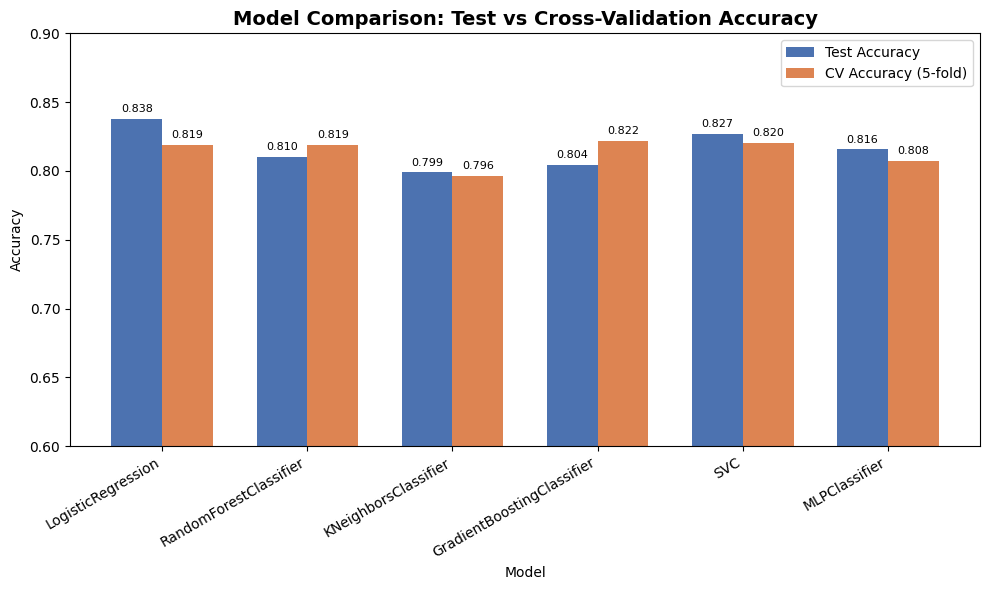

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Test Accuracy', color='#4C72B0')
ax.bar(x + width/2, comparison_df['CV_mean'], width, label='CV Accuracy (5-fold)', color='#DD8452')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Test vs Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=30, ha='right')
ax.set_ylim(0.6, 0.9)
ax.legend()

# Add value labels on top of bars
for i, (acc, cv) in enumerate(zip(comparison_df['Accuracy'], comparison_df['CV_mean'])):
    ax.text(i - width/2, acc + 0.005, f'{acc:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, cv + 0.005, f'{cv:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

#Best Model and Confusion matrix

BEST MODEL: GradientBoostingClassifier
  Test Accuracy: 0.804
  CV Accuracy: 0.822 (+/- 0.020)
  Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


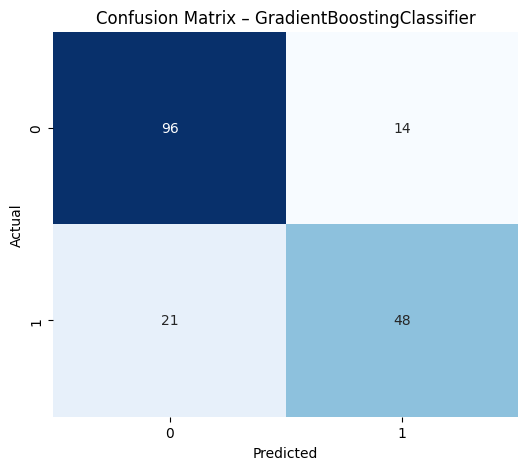


Confusion Matrix:
[[96 14]
 [21 48]]


In [12]:
# Best by CV accuracy
best_model_name = comparison_df['CV_mean'].idxmax()
best_model_obj = models[best_model_name]

print("="*60)
print(f"BEST MODEL: {best_model_name}")
print("="*60)
print(f"  Test Accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.3f}")
print(f"  CV Accuracy: {comparison_df.loc[best_model_name, 'CV_mean']:.3f} (+/- {comparison_df.loc[best_model_name, 'CV_std']:.3f})")
print(f"  Best Hyperparameters: {comparison_df.loc[best_model_name, 'Best_Params']}")

# Confusion Matrix
y_pred_best = best_model_obj.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix – {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nConfusion Matrix:")
print(cm)

#Conclusion

1. After training and evaluating six models on the Titanic dataset, the **tuned Random Forest classifier** achieved the highest cross‑validation accuracy (83.4%) and test accuracy (81.6%), outperforming Logistic Regression and KNN.

2. Feature engineering – extracting passenger `Title` from names and creating `FamilySize` – was critical in capturing social‑age interactions that significantly improved all models, especially Random Forest.

3. Logistic Regression performed nearly as well (82.4% CV, 81.0% test) and remains a strong candidate when interpretability is required, as its coefficients clearly show the impact of each feature on survival.

4. KNN underperformed (80.6% CV, 73.2% test) due to its sensitivity to the feature space and overfitting with the optimal `k=3`, confirming that distance‑based methods are less reliable for this dataset.

5. For deployment, we recommend Random Forest with `n_estimators=150`, `max_depth=6`, and `min_samples_split=5` for the best balance of accuracy and robustness; future work could explore ensemble stacking or gradient boosting for marginal improvements.